In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# Display all columns
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)

print("Shape:", df.shape)
df.head()

Shape: (225464, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225464 entries, 0 to 225463
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 259.7+ MB


In [ ]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,2.254640e+05,0.0,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,2.254640e+05,225462.000000,225464.000000,225464.000000,225464.000000,225464.000000,116200.000000,39984.000000,225464.000000,225464.000000,2.254640e+05,225378.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,2.254640e+05,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,66015.000000,225464.0,511.000000,509.000000,225464.000000,225464.000000,2.254640e+05,21372.000000,21372.000000,21372.000000,21372.000000,20810.000000,21372.000000,18617.000000,21372.000000,21372.000000,21372.000000,21372.000000,2.254640e+05,21372.000000,21372.000000,21372.000000,225464.000000,225464.000000,223392.000000,223253.000000,225464.000000,225464.000000,219056.000000,225464.00000,225464.000000,225464.000000,225464.000000,223457.000000,57443.000000,201179.000000,80913.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,225464.000000,225463.000000,225464.000000,225464.000000,212561.000000,225464.000000,225464.000000,225464.000000,225464.000000,223201.000000,225464.000000,225464.000000,2.254640e+05,2.254640e+05,225464.000000,2.254630e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1589.0,1589.000000,1589.0,1589.000000,1280.000000,1589.000000,1589.000000,6555.000000,6555.000000,6555.000000
mean,6.150534e+07,NaN,15254.532542,15254.532542,15245.969951,12.415985,441.148078,7.798485e+04,19.210678,0.348131,694.353777,698.353897,0.570512,34.152625,65.850965,11.980001,0.234587,1.793658e+04,53.099870,25.376606,920.030525,919.451606,15550.468474,15541.913718,12395.620838,2926.622746,1.965666e+00,226.259219,40.401094,4243.430019,678.222359,662.481106,0.021649,44.054260,1.0,109981.011585,18.310118,0.005735,259.829649,1.421747e+05,1.109021,2.928832,0.761651,1.674574,20.912686,36552.811389,71.580491,1.389060,2.975482,5887.979740,60.881995,3.449967e+04,0.943945,1.537058,2.234091,4.682198,13256.234720,9946.730474,61.562230,0.010521,15.138062,127.674417,187.55133,13.604190,8.002391,

In [ ]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [ ]:
df.shape

(225464, 151)

In [ ]:
# Columns required for our analysis

columns = [
    "loan_amnt",
    "int_rate",
    "grade",
    "sub_grade",
    "annual_inc",
    "purpose",
    "addr_state",
    "loan_status",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "term"
]

loan_df = df[columns].copy()

loan_df.head()

,loan_amnt,int_rate,grade,sub_grade,annual_inc,purpose,addr_state,loan_status,dti,fico_range_low,fico_range_high,term
0,3600.0,13.99,C,C4,55000.0,debt_consolidation,PA,Fully Paid,5.91,675.0,679.0,36 months
1,24700.0,11.99,C,C1,65000.0,small_business,SD,Fully Paid,16.06,715.0,719.0,36 months
2,20000.0,10.78,B,B4,63000.0,home_improvement,IL,Fully Paid,10.78,695.0,699.0,60 months
3,35000.0,14.85,C,C5,110000.0,debt_consolidation,NJ,Current,17.06,785.0,789.0,60 months
4,10400.0,22.45,F,F1,104433.0,major_purchase,PA,Fully Paid,25.37,695.0,699.0,60 months


In [ ]:
loan_df.isnull().sum()

,0
loan_amnt,0
int_rate,0
grade,0
sub_grade,0
annual_inc,0
purpose,0
addr_state,0
loan_status,0
dti,2
fico_range_low,0


In [ ]:
# Remove % from interest rate
loan_df["int_rate"] = (
    loan_df["int_rate"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

# Average FICO Score
loan_df["fico_score"] = (
    loan_df["fico_range_low"] + loan_df["fico_range_high"]
) / 2

# Remove original FICO columns
loan_df.drop(
    ["fico_range_low", "fico_range_high"],
    axis=1,
    inplace=True
)

# Remove rows with missing values
loan_df.dropna(inplace=True)

loan_df.head()

AttributeError: Can only use .str accessor with string values!

In [ ]:
loan_df["int_rate"].head()

,int_rate
0,13.99
1,11.99
2,10.78
3,14.85
4,22.45


In [ ]:
# Create average FICO score
loan_df["fico_score"] = (
    loan_df["fico_range_low"] + loan_df["fico_range_high"]
) / 2

# Drop the original FICO columns
loan_df.drop(
    columns=["fico_range_low", "fico_range_high"],
    inplace=True
)

# Remove missing values
loan_df.dropna(inplace=True)

loan_df.head()

,loan_amnt,int_rate,grade,sub_grade,annual_inc,purpose,addr_state,loan_status,dti,term,fico_score
0,3600.0,13.99,C,C4,55000.0,debt_consolidation,PA,Fully Paid,5.91,36 months,677.0
1,24700.0,11.99,C,C1,65000.0,small_business,SD,Fully Paid,16.06,36 months,717.0
2,20000.0,10.78,B,B4,63000.0,home_improvement,IL,Fully Paid,10.78,60 months,697.0
3,35000.0,14.85,C,C5,110000.0,debt_consolidation,NJ,Current,17.06,60 months,787.0
4,10400.0,22.45,F,F1,104433.0,major_purchase,PA,Fully Paid,25.37,60 months,697.0


In [ ]:
loan_df.dtypes


,0
loan_amnt,float64
int_rate,float64
grade,object
sub_grade,object
annual_inc,float64
purpose,object
addr_state,object
loan_status,object
dti,float64
term,object


In [ ]:
print("=" * 50)
print("LOAN PORTFOLIO SUMMARY")
print("=" * 50)

print(f"Total Loans: {len(loan_df):,}")

print(f"Total Loan Amount: ${loan_df['loan_amnt'].sum():,.2f}")

print(f"Average Loan Amount: ${loan_df['loan_amnt'].mean():,.2f}")

print(f"Average Interest Rate: {loan_df['int_rate'].mean():.2f}%")

print(f"Average Annual Income: ${loan_df['annual_inc'].mean():,.2f}")

print(f"Average FICO Score: {loan_df['fico_score'].mean():.0f}")

LOAN PORTFOLIO SUMMARY
Total Loans: 225,462
Total Loan Amount: $3,439,324,225.00
Average Loan Amount: $15,254.56
Average Interest Rate: 12.42%
Average Annual Income: $77,985.55
Average FICO Score: 696


In [ ]:
loan_df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,158982
Charged Off,39921
Current,25145
Late (31-120 days),859
In Grace Period,394
Late (16-30 days),160
Default,1


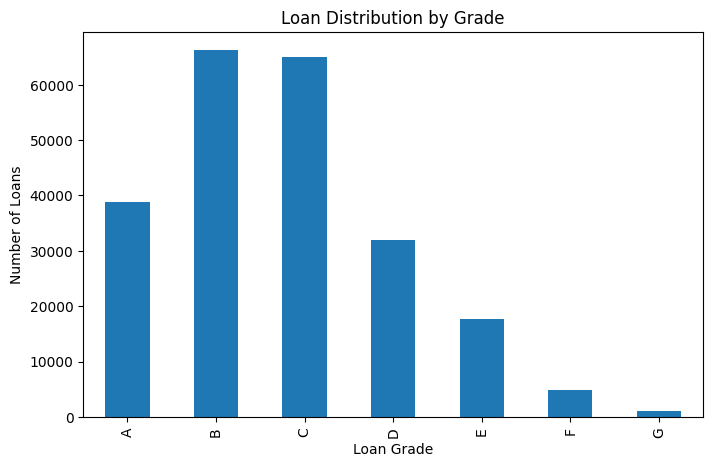

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

loan_df["grade"].value_counts().sort_index().plot(kind="bar")

plt.title("Loan Distribution by Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")

plt.show()

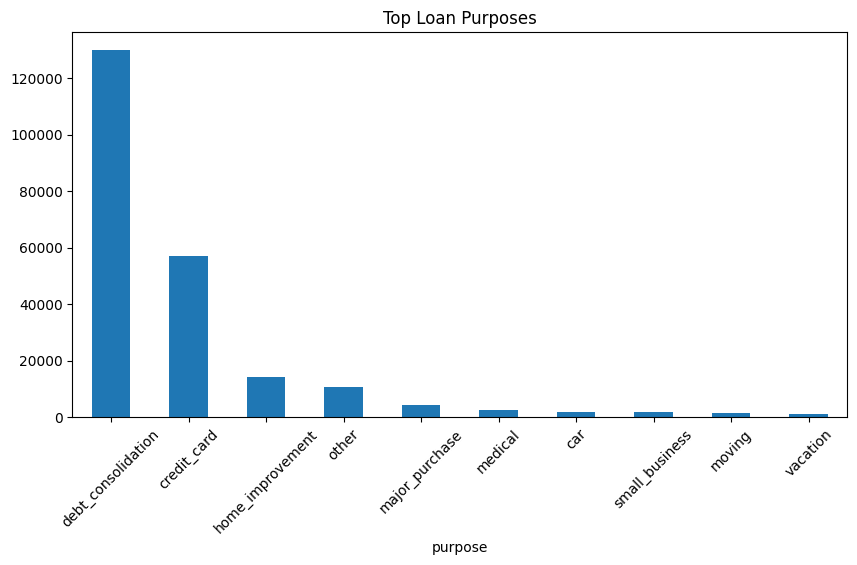

In [ ]:
plt.figure(figsize=(10,5))

loan_df["purpose"].value_counts().head(10).plot(kind="bar")

plt.title("Top Loan Purposes")

plt.xticks(rotation=45)

plt.show()

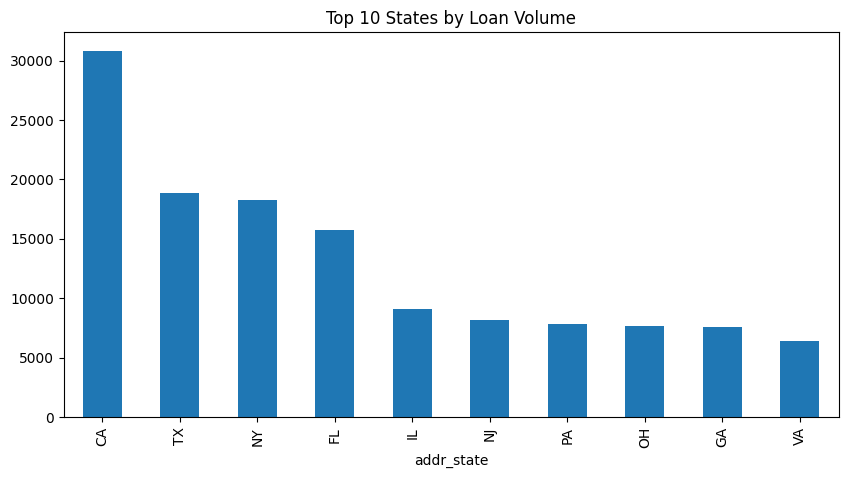

In [ ]:
top_states = loan_df["addr_state"].value_counts().head(10)

plt.figure(figsize=(10,5))

top_states.plot(kind="bar")

plt.title("Top 10 States by Loan Volume")

plt.show()

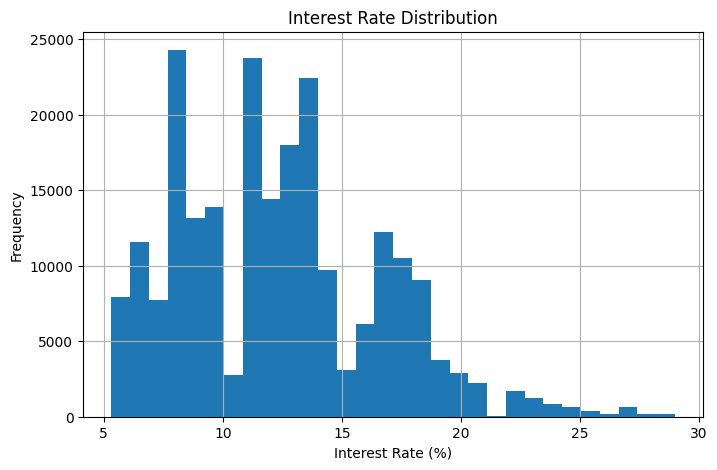

In [ ]:
plt.figure(figsize=(8,5))

loan_df["int_rate"].hist(bins=30)

plt.title("Interest Rate Distribution")

plt.xlabel("Interest Rate (%)")

plt.ylabel("Frequency")

plt.show()

In [ ]:
loan_df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,158982
Charged Off,39921
Current,25145
Late (31-120 days),859
In Grace Period,394
Late (16-30 days),160
Default,1


In [ ]:
# Keep only completed loans
ml_df = loan_df[
    loan_df["loan_status"].isin(["Fully Paid", "Charged Off"])
].copy()

# Create target variable
ml_df["default"] = ml_df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

print(ml_df["default"].value_counts())

default
0    158982
1     39921
Name: count, dtype: int64


In [ ]:
features = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_score"
]

X = ml_df[features]
y = ml_df["default"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

Accuracy: 0.8026

Confusion Matrix
[[31240   557]
 [ 7295   689]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     31797
           1       0.55      0.09      0.15      7984

    accuracy                           0.80     39781
   macro avg       0.68      0.53      0.52     39781
weighted avg       0.76      0.80      0.74     39781



In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
1,int_rate,0.155674
3,dti,0.017583
4,fico_score,-0.005565
0,loan_amnt,0.000015
2,annual_inc,-0.000002


In [28]:
loan_df.to_csv("loan_portfolio_clean.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!
